# Bias Analysis - Study1

## Loading Libraries & Data

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl
import requests
from pathlib import Path
import json
import re
import yfinance as yf
import math
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pingouin as pg
import itertools
from scipy import stats
import string

In [ ]:
ageRisk = pd.read_csv('./processed/ageRisk_long.csv', index_col=0)

## Resolving ETFs 

In [ ]:
# Calculates the weight of a position in a portfolio 
def get_position_weight(portfolio_df):
    position_weight = portfolio_df / portfolio_df.sum()
    return position_weight

ageRisk_select_cols = ['ai', 'age', 'risk-taking', 'iteration', 'ticker_symbol', 'amount_to_invest', 'weight', 'sector', 'asset_type', 'country']
ageRisk['weight'] = ageRisk.groupby(['ai', 'age', 'risk-taking', 'iteration'])['amount_to_invest'].transform(get_position_weight)
ageRisk = ageRisk[ageRisk_select_cols]

ageRisk_unique_etfs = ageRisk[ageRisk["asset_type"] == "ETF"]["ticker_symbol"].unique()
etfs = ageRisk_unique_etfs

ageRisk_unique_funds = ageRisk[ageRisk["asset_type"] == "MUTUALFUND"]["ticker_symbol"].unique()
funds = ageRisk_unique_funds

In [ ]:
etfs

In [ ]:
funds

In [ ]:
resStr_etf = ""
os = ['QQQ', 'SHY', 'VXUS', 'ICLN', 'BND', 'BOTZ', 'IEF', 'TLT', 'SOXX', 'ANGL', 'VCSH', 'REIT']
ks = ['GOVT', 'IEFA', 'ARKK', 'ARKW', 'ARKG', 'NOBL', 'IEMG', 'SCHH']
for etf in etfs:
    if etf in os:
        resStr_etf += f'{etf}.O;'
    elif etf in ks:
        resStr_etf += f'{etf}.K;'
    else:
        resStr_etf += f'{etf};'
resStr_etf

In [ ]:
resStr_mutualFunds = "";
for fund in funds:
    resStr_mutualFunds += f'{fund}.O;'
resStr_mutualFunds

In [ ]:
resStr_funds = resStr_etf + resStr_mutualFunds
resStr_funds

In [ ]:
# BSCM ended on 15.12.2022, GLD, SLV, DbC

## Loading Data from Refinitiv & Resolving Dataset

In [ ]:
# Transforms and cleans a given Refinitiv data set to be usable
def prepare_refinitiv_dataset(df, columns):
    df = df.iloc[1:].reset_index()
    df.columns = columns
    df['economic_sector'] = df['economic_sector'].replace('Unable to resolve all requested identifiers.', np.nan)
    condition = df['country'].str.startswith('Unable to')
    df.loc[condition & ~df['country'].isna(), 'country'] = np.nan
    condition = df['economic_sector'].str.startswith('Unable to')
    df.loc[condition & ~df['economic_sector'].isna(), 'country'] = np.nan
    df['weight'] = pd.to_numeric(df['weight'], errors='coerce')
    df['weight'] = df['weight'].fillna(100.0)
    df['weight'] = df['weight'] / 100
    df['fund'] = df['fund'].str.split('.').str[0]
    return df

# Returns the current asset ticker of a row
def create_ticker(row):
    if row['asset_type'] in ['ETF', 'MUTUALFUND']:
        return row['symbol']
    else:
        return row['ticker_symbol']
        
# Returns the current asset ticker of a row on the second resolving iteration
def create_ticker_l2(row):
    if row['asset_type'] in ['ETF', 'MUTUALFUND']:
        return row['ticker'] if pd.isnull(row['equity_l2']) else row['symbol_l2']
    else:
        return row['ticker']

# Harmonizes Yahoo Finance and Refinitiv sector names
def harmonize_sectors(sector):
    if sector == 'Consumer Cyclicals':
        return 'Consumer Cyclical'
    elif sector == 'Financial Services':
        return 'Financials'
    elif sector == 'Consumer Defensive':
        return 'Consumer Non-Cyclicals'
    else:
        return sector

# Resolves funds into equities (second resolving iteration)
def resolve_layer2(df, select_cols):
    df = df.merge(additional_data, left_on='ticker', right_on='fund', how='left', suffixes=('_l1','_l2'))
    df['weight_l2'].fillna(1, inplace=True)
    df['weight'] = df['weight_l1'] * df['weight_l2']
    df['sector'] = df['sector'].fillna(df['economic_sector_l2'])
    df['country'] = df.apply(
        lambda row: row['country_l2'] if pd.isnull(row['country_l1']) else row['country_l1'],
        axis=1
    )
    df['ticker'] = df.apply(lambda row: create_ticker_l2(row), axis=1)
    df['amount'] = df.apply(lambda row: row['amount'] * row['weight_l2'], axis=1)

    condition = df['country'].str.startswith('Unable to')
    df.loc[condition & ~df['country'].isna(), 'country'] = np.nan
    condition = df['sector'].str.startswith('Unable to')
    df.loc[condition & ~df['sector'].isna(), 'sector'] = np.nan

    df['sector'] = df['sector'].fillna('UNKNOWN')
    df['sector'] = df['sector'].apply(harmonize_sectors)
    df['country'] = df['country'].fillna('UNKNOWN')
    df['ticker'] = df['ticker'].fillna('UNKNOWN')
    #df = df[select_cols]
    return df

# Resolves funds into equities (first resolving iteration)
def prepare_data(df, select_cols):
    df = df.merge(fund_data, left_on='ticker_symbol', right_on='fund', how='left')
    df['weight_y'].fillna(1, inplace=True)
    df['weight'] = df['weight_x'] * df['weight_y']
    df['sector'] = df['sector'].fillna(df['economic_sector'])
    df['sector'] = df.apply(
        lambda row: 'Crypto' if row['asset_type'] == 'CRYPTOCURRENCY' else row['sector'],
        axis=1
    )
    df['country_x'] = df['country_x'].str.upper()
    df['country'] = df.apply(
        lambda row: row['country_y'] if pd.isnull(row['country_x']) else row['country_x'],
        axis=1
    )
    df['ticker'] = df.apply(lambda row: create_ticker(row), axis=1)
    df['amount'] = df.apply(lambda row: row['amount_to_invest'] * row['weight_y'], axis=1)
    df['sector'] = df['sector'].apply(harmonize_sectors) 
    return resolve_layer2(df, select_cols)

# Prepares the benchmark for comparison
def prepare_benchmark(df):
    df = df.rename(columns={'economic_sector': 'sector'})
    df['amount'] = df['weight'].apply(lambda x: x * 10000)
    df['sector'] = df['sector'].fillna('UNKNOWN')
    df['country'] = df['country'].fillna('UNKNOWN')
    df['sector'] = df['sector'].apply(harmonize_sectors)
    return df
 
cols_refinitiv = ['fund', 'code', 'equity', 'symbol', '#shares', 'weight', 'country', 'type', 'economic_sector']
etf_data = pd.read_csv('./etf_holdings/refinitiv/etfs_refinitiv.csv', index_col=0)
etf_data = prepare_refinitiv_dataset(etf_data, cols_refinitiv)

mutualFund_data = pd.read_csv('./mutualFund_holdings/refinitiv/mutualFunds_refinitiv.csv', index_col=0)
mutualFund_data = mutualFund_data.iloc[:,:-2]
mutualFund_data = prepare_refinitiv_dataset(mutualFund_data, cols_refinitiv)

fund_data = pd.concat([etf_data, mutualFund_data], ignore_index=True)

additional_data = pd.read_csv('./etf_holdings/refinitiv/additions_refinitiv.csv', index_col=0)
additional_data = prepare_refinitiv_dataset(additional_data, cols_refinitiv)
additional_data = pd.concat([fund_data, additional_data], ignore_index=True)

ageRisk_select_cols = ['ai', 'age', 'risk-taking', 'iteration', 'asset_type', 'ticker', 'weight', 'country', 'sector', 'amount']
ageRisk_resolved = prepare_data(ageRisk, ageRisk_select_cols)

benchmark_cols_refinitiv = ['fund', 'equity', 'symbol', '#shares', 'weight', 'country', 'economic_sector', 'business_sector', 'industry_group']
benchmark = pd.read_csv('./benchmark/refinitiv/benchmarks_refinitiv.csv', index_col=0)
benchmark_prepared = prepare_benchmark(prepare_refinitiv_dataset(benchmark, benchmark_cols_refinitiv))

In [ ]:
benchmark_ftse = benchmark_prepared[benchmark_prepared['fund'] == 'VFAWF']
benchmark_msci = benchmark_prepared[benchmark_prepared['fund'] == 'IUSQ']
benchmark_vt = pd.read_csv('../study1/benchmark/refinitiv/benchmark_vt.csv', index_col=0)

In [ ]:
# Fills a data frame with missing rows to contain all possible experimental configurations
def prepare_dataframe(df, col_name, sep_col = None, sep_col_values = None):
    ais = ['Gemini', 'Copilot', 'ChatGPT']
    ages = [15, 30, 50]
    risk_taking = ['averse', 'neutral', 'seeking']
    iterations = list(range(10))  # 0 to 9
    
    if sep_col:
        combinations = list(itertools.product(ais, ages, risk_taking, iterations, sep_col_values))

        missing_rows = pd.DataFrame(combinations, columns=['ai', 'age', 'risk-taking', 'iteration', sep_col])
        missing_rows[col_name] = 0

        result_df = df.merge(missing_rows, on=['ai', 'age', 'risk-taking', 'iteration', sep_col], how='outer', suffixes=('', '_missing'))
        result_df[col_name].fillna(0, inplace=True)
        return result_df
    else:
        combinations = list(itertools.product(ais, ages, risk_taking, iterations))
        
        missing_rows = pd.DataFrame(combinations, columns=['ai', 'age', 'risk-taking', 'iteration'])
        missing_rows[col_name] = 0

        result_df = df.merge(missing_rows, on=['ai', 'age', 'risk-taking', 'iteration'], how='outer', suffixes=('', '_missing'))
        result_df[col_name].fillna(0, inplace=True)
        return result_df

## Graphs

In [ ]:
mpl.rcParams['font.size'] = 14
mpl.rcParams['font.sans-serif'] = 'Arial'

In [ ]:
# Returns a data frame that contains all combinations of two data frames on a certain criterion (elem)
def fill_options(filtered_df, res_df, elem, group_cols):
    elems = filtered_df[elem].unique()
    group_cols_df = filtered_df[group_cols].drop_duplicates()
    all_combinations = pd.DataFrame([row + [el] for row in group_cols_df.values.tolist() for el in elems], columns=group_cols+[elem])
    merged = pd.merge(all_combinations, res_df, on=group_cols+[elem], how='left')
    merged.fillna(0, inplace=True)
    return merged

# Calculates the weight of a certain characteristic (elem) in a group
def calculate_weight(group, elem):
    summed = group.groupby(elem)['amount'].sum().reset_index()
    total_amount = summed['amount'].sum()
    summed['weight'] = summed['amount'] / total_amount
    return summed

# Prepares benchmark data to be handled as a experimental condition
def create_benchmark_dummy(df, benchmark_label):
    benchmark_ai = f'{benchmark_label}'
    df['cond'] = benchmark_ai
    df['ai'] = benchmark_ai
    df['age'] = 1
    df['risk-taking'] = 'low'
    df['iteration'] = 0
    return df

# Calculates an ANOVA on a characteristic (column) for the defined groups (group1, group2) and prints the TukeyHSD results
def show_anova(df, column, group1, group2=None, onlyGroup=False):
    if group1 and group2:
        df['label'] = df.apply(lambda row: f"({row[group1]}, {row[group2]})", axis=1)
    else:
        df = df.copy()
        df.loc[:, 'label'] = df.loc[:, group1]
    
    model = ols(f'{column} ~ label', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)
    tukey_results = pairwise_tukeyhsd(endog=df[column], groups=df['label'], alpha=0.05)
    print(tukey_results)
    #pairwise_results = pg.pairwise_tests(data=df, dv=column, between='label', effsize='cohen', padjust='holm')
    #contrasts = pairwise_results[['A', 'B', 'p-corr', 'cohen']]
    #print(contrasts)
    #pairwise_results = pg.pairwise_tests(data=df, dv=column, between='label', effsize='cohen', correct)
    #print(pairwise_results[['A', 'B', 'p-unc', 'cohen']])
    
# Calculates a t-test between a sample and a fixed value for a defined grouping
def show_ttest(raw, column, groups, benchmark):
    for group_name, group_data in raw.groupby(groups):
        group_values = group_data[column]
        t_statistic, p_value = stats.ttest_1samp(group_values, benchmark)
        d = group_values.mean() - benchmark
        print(f'group: {group_name} got t: {round(t_statistic,2)} p_value: {round(p_value,4)} dfs: {len(group_values)-1} benchmark: {round(benchmark, 2)} d: {round(d, 2)}')

# Calculates statistics for a given characteristic (column) within groups
def calc_stats(raw, column, benchmark, group1, group2=None, onlyGroup=False):
    show_anova(raw, column, group1, group2, onlyGroup)
    groups = [group1, group2] if group2 != None else [group1]
    show_ttest(raw, column, groups, benchmark)
    
    grouped = raw.groupby(groups)[column]
    means = []
    std_devs = []
    sample_sizes = []
    if len(groups) > 1:
        means = grouped.mean().unstack()
        std_devs = grouped.std().unstack()
        sample_sizes = grouped.count().unstack()
    else:
        means = grouped.mean()
        std_devs = grouped.std()
        sample_sizes = grouped.count()
    standard_errors = std_devs / np.sqrt(sample_sizes)
    return means, std_devs, sample_sizes, standard_errors

# Prints means, standard deviations, and sample sizes for defined groups
def print_stats(raw, column, benchmark, group1, group2=None, onlyGroup=False):
    means, std_devs, sample_sizes, standard_errors = calc_stats(raw, column, benchmark, group1, group2, onlyGroup)
    
    print(f'means:\n{round(means, 2)}')
    print(f'stds:\n{round(std_devs,2)}')
    print(sample_sizes)
    return means, std_devs, sample_sizes, standard_errors
    
# Prints mean violinplots of a feature relative to a fixed benchmark value
def show_benchmark_violinplot(raw, benchmark, benchmark_label, column, column_label, group1, filename):
    means, _, _,_ = print_stats(raw, column, benchmark, group1)
    
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.violinplot(data=raw, x=group1, y=column, split=False, inner=None, linewidth=1, ax=ax, edgecolor='black', fill=None, zorder=2)

    # Add boxplots
    sns.boxplot(data=raw, x=group1, y=column, hue=group1, width=0.2, palette="Set3", ax=ax, 
                boxprops=dict(edgecolor='black', facecolor=(1, 1, 1, 0)), 
                medianprops=dict(linewidth=2, color='black'), 
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'), fliersize=0, legend=False, zorder=4)

    colors = {'ChatGPT': '#19C37D', 'Copilot': '#106EBE', 'Gemini': '#7f7dd1'}
    for i, group in enumerate(raw[group1].unique()):
        group_data = raw[raw[group1] == group][column]
        jitter = np.random.normal(i, 0.04, size=len(group_data))
        ax.scatter(jitter, group_data, s=100, alpha=0.4, zorder=3, color=colors[group])  # Set zorder to ensure dots are on top

        # Calculate the mean and add it to the boxplot
        mean = group_data.mean()
        ax.scatter(i, mean, color='black', s=50, label='mean', zorder=5)

    ax.axhline(y=benchmark, color='black', linestyle='--', label=benchmark_label, zorder=4)
    ax.set_ylabel(column_label)
    ax.set_xticks(range(len(means.index)))
    ax.set_xticklabels(means.index, rotation=0, ha='center')
    ax.set_xlabel('LLM')
    ax.grid(True, zorder=1)
    ax.text(1.02, benchmark, benchmark_label, va='center', ha="left", bbox=dict(facecolor='none', edgecolor='none', boxstyle='round,pad=0.2'), transform=ax.get_yaxis_transform())

    plt.subplots_adjust(hspace=1)
    plt.tight_layout()
    if filename is not None:
        plt.savefig(f'./figures/{filename}.png')
    plt.show()

# Prints mean barplots of a feature relative to a fixed benchmark value
def print_benchmark_errplot(means, standard_errors, benchmark, benchmark_label, column_label):
    # Create a stacked barplot with error bars
    ax = means.plot(kind='bar', stacked=False, yerr=standard_errors.values.T, capsize=5, figsize=(4, 5), zorder=2, color=['darkgrey'])
    ax.axhline(y=benchmark, color='red', linestyle='--', label=benchmark_label)
    ax.set_ylabel(column_label)
    ax.set_xticklabels(means.index, rotation=0, ha='center')
    ax.set_xlabel('LLM')
    ax.grid(True, zorder=1)
    ax.annotate(benchmark_label, xy=(0, benchmark), xytext=(0, 1),
            color='red', fontsize=10, ha='left', va='bottom', textcoords='offset points')

    # Show the plot
    plt.subplots_adjust(hspace=1)
    plt.tight_layout()
    plt.show()
    
# Prints the mean barplots without printing the means, stds, and sample_sizes
def show_benchmark_errplot(raw, benchmark, benchmark_label, column, column_label, group1, group2=None):
    means, std_devs, sample_sizes, standard_errors = calc_stats(raw, column, benchmark, group1, group2)
    print_benchmark_errplot(means, standard_errors, benchmark, benchmark_label, column_label)

# Prints the mean barplots and prints the means, stds, and sample_sizes
def show_benchmark_errplot_complete(raw, benchmark, benchmark_label, column, column_label, group1, group2=None):
    means, std_devs, sample_sizes, standard_errors = print_stats(raw, column, benchmark, group1, group2)
    print_benchmark_errplot(means, standard_errors, benchmark, benchmark_label, column_label)

# Transforms values into percent values
def rescale(df, col):
    res = df.copy()
    res[col] = res[col] * 100
    return res

group_cols = ['ai', 'age', 'risk-taking', 'iteration']
vt_dummy = create_benchmark_dummy(benchmark_vt, 'VT')


## Geographic cluster risk

In [ ]:
# Calculates the US and Non-US share of investment assets
def prepare_geographic_data(df, is_benchmark = False):
    df = df.copy()
    if not is_benchmark:
        df = df[df['asset_type'].isin(['ETF', 'EQUITY', 'MUTUALFUND'])]
    df = df[df['country'] != 'UNKNOWN'] 
    df['country'] = df['country'].apply(lambda x: 'US' if x == 'UNITED STATES' else 'Non-US')
    print(df.shape)
    return df

benchmark_filtered = prepare_geographic_data(vt_dummy, True)
geo_benchmark = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
geo_benchmark_us = geo_benchmark[geo_benchmark['country']=='US'].iloc[0]['weight']
geo_benchmark_us = geo_benchmark_us * 100

filtered_df = prepare_geographic_data(ageRisk_resolved)
geo = filtered_df.groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
#geo = prepare_dataframe(geo, 'weight', 'country', geo['country'].unique()) #leave data point out since no classification possible
geo_us = geo[geo['country']=='US']
geo_us = rescale(geo_us, 'weight')

In [ ]:
show_benchmark_violinplot(
    geo_us, 
    geo_benchmark_us, 
    'Benchmark (VT)', 
    'weight',
    'Geographic Cluster Risk',
    'ai',
    'study1_geoRisk'
)

In [ ]:
# Control for different sample sizes due to exclusion criteria
geo_risk_chatgpt = geo_us[geo_us['ai'] == 'ChatGPT']['weight']
geo_risk_copilot = geo_us[geo_us['ai'] == 'Copilot']['weight']
geo_risk_gemini = geo_us[geo_us['ai'] == 'Gemini']['weight']

# Mann-Whitney U test
stat, p = stats.mannwhitneyu(geo_risk_chatgpt, geo_risk_copilot)
print(f'ChatGPT-Copilot: {stat}, {p}')
stat, p = stats.mannwhitneyu(geo_risk_copilot, geo_risk_gemini)
print(f'Copilot-Gemini: {stat}, {p}')
stat, p = stats.mannwhitneyu(geo_risk_chatgpt, geo_risk_gemini)
print(f'ChatGPT-Gemini: {stat}, {p}')

# One-sample Wilcoxon signed-rank test
stat_bench, p_bench = stats.wilcoxon(geo_risk_chatgpt - geo_benchmark_us)
print(f'ChatGPT-benchmark: {stat_bench}, {p_bench}')
stat_bench, p_bench = stats.wilcoxon(geo_risk_copilot - geo_benchmark_us)
print(f'Copilot-benchmark: {stat_bench}, {p_bench}')
stat_bench, p_bench = stats.wilcoxon(geo_risk_gemini - geo_benchmark_us)
print(f'Gemini-benchmark: {stat_bench}, {p_bench}')

# Perform Chi-Square test
count_chatgpt = [90-geo_risk_chatgpt.size, geo_risk_chatgpt.size]
count_copilot = [90-geo_risk_copilot.size, geo_risk_copilot.size]
count_gemini = [90-geo_risk_gemini.size, geo_risk_gemini.size]

chi2_stat, p_chi, df_chi, expected = stats.chi2_contingency([count_chatgpt, count_copilot])
print(f'chi-square: {chi2_stat}, {p_chi}, df:{df_chi}')
chi2_stat, p_chi, df_chi, expected = stats.chi2_contingency([count_copilot, count_gemini])
print(f'chi-square: {chi2_stat}, {p_chi}, df:{df_chi}')
chi2_stat, p_chi, df_chi, expected = stats.chi2_contingency([count_chatgpt, count_gemini]) # expected error since same number of successes
print(f'chi-square: {chi2_stat}, {p_chi}, df:{df_chi}')


In [ ]:
unused = print_stats(geo_us, 'weight', geo_benchmark_us, 'ai', 'risk-taking')

In [ ]:
unused = print_stats(geo_us, 'weight', geo_benchmark_us, 'ai', 'age')

## Sector cluster risk

In [ ]:
# Selects only investment assets and removes rows with unknown sector form the data
def prepare_sector_data(df, is_benchmark = False):
    if not is_benchmark:
        df = df[df['asset_type'].isin(['ETF', 'EQUITY', 'MUTUALFUND'])]
    df = df[df['sector'] != 'UNKNOWN'] 
    print(df.shape)
    return df

# Calculates the sector concentration
def calculate_concentration(result, group):
    result['weight_squared'] = result['weight'] ** 2
    result_sum = result.groupby(group)['weight'].sum().reset_index()
    result_sum = result_sum['weight'] ** 2
    result_grouped = result.groupby(group)['weight_squared'].sum().reset_index()
    result_grouped['concentration'] = result_grouped['weight_squared'] / result_sum
    return result_grouped

benchmark_filtered = prepare_sector_data(vt_dummy, True)
sec_benchmark = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
sec_benchmark = calculate_concentration(sec_benchmark, group_cols)
sec_benchmark = sec_benchmark.iloc[0]['concentration']

filtered_df = prepare_sector_data(ageRisk_resolved)
sec = filtered_df.groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
#sec = prepare_dataframe(sec, 'weight', 'sector', sec['sector'].unique()) #left out as before due to lack of classification
sec = calculate_concentration(sec, group_cols)

In [ ]:
show_benchmark_violinplot(
    sec, 
    sec_benchmark, 
    'Benchmark (VT)', 
    'concentration',
    'Sector Cluster Risk', #Sector Concentration 
    'ai',
    'study1_sectorRisk'
)

In [ ]:
# Control for different sample sizes due to exclusion criteria
sec_risk_chatgpt = sec[sec['ai'] == 'ChatGPT']['concentration']
sec_risk_copilot = sec[sec['ai'] == 'Copilot']['concentration']
sec_risk_gemini = sec[sec['ai'] == 'Gemini']['concentration']

# Mann-Whitney U test
stat, p = stats.mannwhitneyu(sec_risk_chatgpt, sec_risk_copilot)
print(f'ChatGPT-Copilot: {stat}, {p}')
stat, p = stats.mannwhitneyu(sec_risk_copilot, sec_risk_gemini)
print(f'Copilot-Gemini: {stat}, {p}')
stat, p = stats.mannwhitneyu(sec_risk_chatgpt, sec_risk_gemini)
print(f'ChatGPT-Gemini: {stat}, {p}')

# One-sample Wilcoxon signed-rank test
stat_bench, p_bench = stats.wilcoxon(sec_risk_chatgpt - sec_benchmark)
print(f'ChatGPT-benchmark: {stat_bench}, {p_bench}')
stat_bench, p_bench = stats.wilcoxon(sec_risk_copilot - sec_benchmark)
print(f'Copilot-benchmark: {stat_bench}, {p_bench}')
stat_bench, p_bench = stats.wilcoxon(sec_risk_gemini - sec_benchmark)
print(f'Gemini-benchmark: {stat_bench}, {p_bench}')

# Perform Chi-Square test
count_chatgpt = [90-sec_risk_chatgpt.size, sec_risk_chatgpt.size]
count_copilot = [90-sec_risk_copilot.size, sec_risk_copilot.size]
count_gemini = [90-sec_risk_gemini.size, sec_risk_gemini.size]

chi2_stat, p_chi, df_chi, expected = stats.chi2_contingency([count_chatgpt, count_copilot])
print(f'chi-square: {chi2_stat}, {p_chi}, df:{df_chi}')
chi2_stat, p_chi, df_chi, expected = stats.chi2_contingency([count_copilot, count_gemini])
print(f'chi-square: {chi2_stat}, {p_chi}, df:{df_chi}')
chi2_stat, p_chi, df_chi, expected = stats.chi2_contingency([count_chatgpt, count_gemini]) # expected error since same number of successes
print(f'chi-square: {chi2_stat}, {p_chi}, df:{df_chi}')


In [ ]:
unused = print_stats(sec, 'concentration', sec_benchmark, 'ai', 'risk-taking')

In [ ]:
unused = print_stats(sec, 'concentration', sec_benchmark, 'ai', 'age')

## Concentration Map

In [ ]:
# Selects only investment assets and assets with known country and sector
def prepare_overview_data(df, isBenchmark = False):
    filtered_df = df.copy()
    if not isBenchmark:
        filtered_df = df[df['asset_type'].isin(['ETF', 'EQUITY', 'MUTUALFUND'])]
    filtered_df = filtered_df[filtered_df['country'] != 'UNKNOWN'] 
    filtered_df = filtered_df[filtered_df['sector'] != 'UNKNOWN']
    filtered_df['country'] = filtered_df['country'].apply(lambda x: 'US' if x == 'UNITED STATES' else 'Non-US')
    print(filtered_df.shape)
    return filtered_df

# Calculates the means, stds, and sample sizes
def calc_overview(raw, column, column_label, group1, group2=None):
    show_anova(raw, column, group1, group2)
    groups = [group1, group2] if group2 != None else [group1]    
    grouped = raw.groupby(groups)[column]
    means = []
    std_devs = []
    sample_sizes = []
    if len(groups) > 1:
        means = grouped.mean().unstack()
        std_devs = grouped.std().unstack()
        sample_sizes = grouped.count().unstack()
    else:
        means = grouped.mean()
        std_devs = grouped.std()
        sample_sizes = grouped.count()
    standard_errors = std_devs / np.sqrt(sample_sizes)
    
    print(f'means:\n{round(means, 4)}')
    print(f'stds:\n{round(std_devs,4)}')
    print(sample_sizes)

# Calculates the t-test between a sample and a fixed value across groups
def show_matched_ttest(raw, column, benchmark):
    for group_name, group_data in raw.groupby(column):
        group_values = group_data['weight']
        benchmark_val = 0
        if len(benchmark[benchmark[column] == group_name]) > 0:
            benchmark_val = benchmark[benchmark[column] == group_name].iloc[0]['weight']
        t_statistic, p_value = stats.ttest_1samp(group_values, benchmark_val)
        print(f'group: {group_name} with mean {round(group_values.mean(),4)} and std {round(group_values.std(),4)} got t: {round(t_statistic,2)} p_value: {round(p_value,4)} dfs: {len(group_values)-1} benchmark: {round(benchmark_val, 4)} and dif: {round(group_values.mean()-benchmark_val, 4)}')

filtered_df = prepare_overview_data(ageRisk_resolved)

sec_ov = filtered_df.groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
sec_ov = fill_options(filtered_df, sec_ov, 'sector', group_cols)
calc_overview(sec_ov, 'weight','weight','sector')

bench_sec_ov = prepare_overview_data(vt_dummy, True).groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
show_matched_ttest(sec_ov, 'sector', bench_sec_ov)

geo_ov = filtered_df.groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
gec_ov = fill_options(filtered_df, geo_ov, 'country', group_cols)
calc_overview(geo_ov, 'weight','weight','country')

bench_geo_ov = prepare_overview_data(vt_dummy, True).groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
show_matched_ttest(geo_ov, 'country', bench_geo_ov)


In [ ]:
# Creates a data frame which contains all combinations of countries and sectors within each portfolio
def fill_concentration(filtered_df, res, group_cols):
    sectors = filtered_df['sector'].unique()
    countries = filtered_df['country'].unique()
    group_cols_df = filtered_df[group_cols].drop_duplicates()
    all_combinations = pd.DataFrame(
        [row + [sector, country] for row in group_cols_df.values.tolist() for sector, country in itertools.product(sectors, countries)], 
        columns=group_cols+['sector', 'country'])

    merged_df = pd.merge(all_combinations, res, on=group_cols+['sector', 'country'], how='left')
    merged_df.fillna(0, inplace=True)
    return merged_df

# Prints a Seaborn heatmap
def custom_heatmap(data, color_map="gray_r", annot=True, fmt=".2%", ax=None, max_color=None, **kwargs):
    sns.heatmap(data, cmap=color_map, annot=annot, fmt=fmt, linewidths=.5, cbar=False, ax=ax, vmax=max_color, **kwargs)

# Prints a sector, country concentration map in horizontal orientation
def show_faceted_heatmap_horizontal(combined_df, filename, show_top, width, height):
    all_sectors = combined_df['sector'].unique()

    g = sns.FacetGrid(combined_df, col="type", col_wrap=1, height=3, aspect=1.5, sharey=True)
    g.fig.set_size_inches(width, height)
    
    first_facet_data = combined_df[combined_df['type'] == combined_df['type'].unique()[0]]
    first_facet_pivot = first_facet_data.pivot_table(index='country', columns='sector', values='weight', fill_value=0)
    max_color_value = combined_df['weight'].max()

    if show_top:
        column_order = first_facet_pivot.sum(axis=0).sort_values(ascending=False).nlargest(5).index
    else:
        column_order = first_facet_pivot.sum(axis=0).sort_values(ascending=False).index

    for i, (ax, facet_name) in enumerate(zip(g.axes, combined_df['type'].unique())):
        ax.set_title(f'Panel {string.ascii_uppercase[i]}: {facet_name} Portfolio Weights')        
        facet_data = combined_df[combined_df['type'] == facet_name]
        facet_pivot = facet_data.pivot_table(index='country', columns='sector', values='weight', fill_value=0)
        facet_pivot = facet_pivot.sort_index(ascending=False)
        facet_pivot = facet_pivot.reindex(columns=column_order, fill_value=0)
        custom_heatmap(facet_pivot, ax=ax, max_color=max_color_value)        
        if i == len(combined_df['type'].unique()) - 1:
            if ax.get_xticklabels():
                ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        else:
            ax.set_xticklabels([])
            ax.tick_params(bottom=False)

    x_label = 'Top 5 Sectors' if show_top else 'Sector'
    g.set_axis_labels(x_label, "Country")
    plt.savefig(f'./figures/{filename}.png', bbox_inches='tight')

# Prints a sector, country concentration map in vertical orientation
def show_faceted_heatmap(combined_df, filename, show_top, width, height):
    all_sectors = combined_df['sector'].unique()

    g = sns.FacetGrid(combined_df, col="type", col_wrap=1, height=3, aspect=1.5, sharey=True)
    g.fig.set_size_inches(width, height)
    
    first_facet_data = combined_df[combined_df['type'] == combined_df['type'].unique()[0]]
    first_facet_pivot = first_facet_data.pivot_table(index='sector', columns='country', values='weight', fill_value=0)
    max_color_value = combined_df['weight'].max()

    if show_top:
        row_order = first_facet_pivot.sum(axis=1).sort_values(ascending=False).nlargest(5).index
    else:
        row_order = first_facet_pivot.sum(axis=1).sort_values(ascending=False).index

    for i, (ax, facet_name) in enumerate(zip(g.axes, combined_df['type'].unique())):
        ax.set_title(f'Panel {string.ascii_uppercase[i]}: {facet_name} Portfolio Weights')        
        facet_data = combined_df[combined_df['type'] == facet_name]
        facet_pivot = facet_data.pivot_table(index='sector', columns='country', values='weight', fill_value=0)
        facet_pivot = facet_pivot.sort_index(ascending=False)
        facet_pivot = facet_pivot.reindex(index=row_order, fill_value=0)
        facet_pivot = facet_pivot.reindex(columns=facet_pivot.columns[::-1], fill_value=0)  # Reverse column order
        custom_heatmap(facet_pivot, ax=ax, max_color=max_color_value)        
        ax.set_yticks(np.arange(len(facet_pivot.index)) + 0.5)
        ax.set_yticklabels(facet_pivot.index, va='center')  # Set y-tick labels
        if i == len(combined_df['type'].unique()) - 1:
            if ax.get_xticklabels():
                ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
        else:
            ax.set_xticklabels([])
            ax.tick_params(bottom=False)

    y_label = 'Top 5 Sectors' if show_top else 'Sector'
    g.set_axis_labels("Country", y_label)
    plt.savefig(f'./figures/{filename}.png', bbox_inches='tight')

benchmark_filtered = prepare_overview_data(vt_dummy, True)
benchmark_concentration = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem=['sector', 'country']).reset_index()
benchmark_concentration = fill_concentration(benchmark_filtered, benchmark_concentration, group_cols)
benchmark_concentration['type'] = 'Benchmark'

concentration = filtered_df.groupby(group_cols).apply(calculate_weight, elem=['sector', 'country']).reset_index()
concentration = fill_concentration(filtered_df, concentration, group_cols)
concentration_overview = concentration.copy()
concentration_overview['type'] = 'LLMs'
concentration_details = concentration.copy()
concentration_details['type'] = concentration_details['ai'] 

combined = pd.concat([concentration_overview, benchmark_concentration], ignore_index=True)

show_faceted_heatmap(combined, 'study1_overview_concentration_map', True, 4, 4)
show_faceted_heatmap(combined, 'study1_concentration_map', False, 4, 8)

combined_details = pd.concat([concentration_details, benchmark_concentration], ignore_index=True)

show_faceted_heatmap(combined_details, 'study1_concentration_map_details', False, 4, 14)
show_faceted_heatmap_horizontal(combined, 'study1_concentration_map_overview_horizontal', True, 5, 4)
show_faceted_heatmap_horizontal(combined_details, 'study1_concentration_map_details_horizontal', False, 12, 8 )

In [ ]:
for risk in combined_details['risk-taking'].unique():
    print(f'for risk: {risk}')
    subset = combined_details[combined_details['risk-taking'] == risk]
    show_faceted_heatmap_horizontal(subset, f'study1_concentration_map_risk_{risk}', False, 12, 8 )
    

In [ ]:
combined_details['ai'].unique()

In [ ]:
for risk in combined_details['risk-taking'].unique():
    print(f'for risk: {risk}')
    for age in combined_details['age'].unique():
        print(f'for age: {age}')
        subset = combined_details[((combined_details['age'] == age) & (combined_details['risk-taking'] == risk)) | (combined_details['ai'] == 'VT')]
        show_faceted_heatmap_horizontal(subset, f'study1_concentration_map_age_{risk}_{age}', False, 12, 8 )

In [ ]:
for age in combined_details['age'].unique():
    print(f'for Copilot age: {age}')
    subset = combined_details[(combined_details['age'] == age) & (combined_details['ai'] == 'Copilot')]
    show_faceted_heatmap_horizontal(subset, f'study1_concentration_map_age_{age}', False, 12, 8 )

In [ ]:
import plotly_express as px
import kaleido

selected_sectors = ['Technology', 'Consumer Cyclical', 'Healthcare', 'Real Estate', 'Government']
replacements = {'Benchmark': 'Benchmark (VT)'}
combined['type'] = combined['type'].replace(replacements)
replacements = {'Government Activity': 'Government'}
combined['sector'] = combined['sector'].replace(replacements)
combined_grouped = combined.groupby(['sector', 'country', 'type'])['weight'].mean().reset_index()

filtered_df = combined_grouped[combined_grouped['sector'].isin(selected_sectors)]
filtered_df = filtered_df.copy()
filtered_df['weight'] = filtered_df['weight'] * 100


fig = px.bar(filtered_df, x="country", y="weight", facet_col="sector", barmode='group', color="type", color_continuous_scale='Greys', 
             category_orders={'sector': selected_sectors,
                             'type':['LLMs', 'Benchmark (VT)']}
            )
fig.update_layout(
    xaxis={'categoryorder':'array', 'categoryarray':['US','Non-US']}, 
    legend_title='', 
    yaxis_title='Portfolio Weight [%]')
fig.update_layout(
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
)
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey')
fig.for_each_annotation(lambda a: a.update(text = a.text.replace("sector=", "")))
fig.update_layout()
fig.update_xaxes(tickangle=0, title=None)
fig.update_layout(autosize=False, width=800, height=400)

fig.write_image('./figures/concentration.png')

fig.show()

## Active investment allocation risk

In [ ]:
ter_data_study1 = pd.read_csv('../study1/etf_holdings/refinitiv/funds_ter_refinitiv.csv', index_col=0)
ter_data_study1 = ter_data_study1.iloc[1:].reset_index()
ter_data_study1.columns = ['fund', 'fund_type', 'ter', 'management_approach']
ter_data_study1 = ter_data_study1[~ter_data_study1['management_approach'].isna()]
ter_data_study3 = pd.read_csv('../study2b/data/refinitiv/funds_ter_refinitiv.csv', index_col=0)
ter_data_study3 = ter_data_study3.iloc[1:].reset_index()
ter_data_study3.columns = ['fund', 'fund_type', 'ter', 'management_approach']

ter_data = pd.concat([ter_data_study1, ter_data_study3], ignore_index=True)
ter_data['fund'] = ter_data['fund'].str.split('.').str[0]
condition = ter_data['ter'].str.startswith('Unable to')
ter_data.loc[condition & ~ter_data['ter'].isna(), 'ter'] = np.nan

In [ ]:
# Sets the management approach depending on the asset type
def set_management_approach(row):
    if row['asset_type'] in ['EQUITY', 
                               'CRYPTOCURRENCY', 
                               'BOND', 
                               'MONEYMARKET', 
                               'SEEDINVEST', 
                               'REALESTATE', 
                               'ROBO', 
                               'VENTURECAPITAL',
                               'PRIVATEEQUITY']:
        return 'Active'
    else:
        ticker = row['ticker_symbol']
        if ticker in ter_data['fund'].unique():
            approach = ter_data[ter_data['fund'] == ticker].iloc[0]['management_approach']
            return approach
        else:
            return 'UNKNOWN'

# Calculates the management approach share within each portfolio
def calculate_approach_weight(group):
    summed = group.groupby('management_approach')['amount_to_invest'].sum().reset_index()
    total_amount = summed['amount_to_invest'].sum()
    summed['management_weight'] = summed['amount_to_invest'] / total_amount
    return summed

# Selects only assets where the management approach is known and calculates the management approach share per portfolio
def get_management_data(df, groups):
    df = df[df['management_approach'] != 'UNKNOWN']
    management_data = df.groupby(groups).apply(calculate_approach_weight).reset_index()
    return management_data      

investment_ageRisk = ageRisk[~ageRisk['asset_type'].isin(['SAVING', 'DEPOSIT', 'IRA', 'ANNUITY'])]
investment_ageRisk = investment_ageRisk.copy()
investment_ageRisk['management_approach'] = investment_ageRisk.apply(set_management_approach, axis=1)
management_data = get_management_data(investment_ageRisk, group_cols)
management_data = prepare_dataframe(management_data, 'management_weight', 'management_approach', ['Active', 'Passive']) # required to include rows where everything is passive
management_data = management_data[management_data['management_approach'] == 'Active']
management_data['management_weight'] = management_data['management_weight'] *100


In [ ]:
show_benchmark_violinplot(
    management_data, 
    0, 
    'Benchmark (VT)', 
    'management_weight',
    'Active Investment Allocation Risk', #Active management portfolio weight [%]
    'ai',
    'study1_activeRisk'
)

In [ ]:
unused = print_stats(management_data, 'management_weight', 0, 'ai', 'risk-taking')

In [ ]:
unused = print_stats(management_data, 'management_weight', 0, 'ai', 'age')

## Total Expense Risk

In [ ]:
fund_identifiers = ter_data['fund'].unique()

# Assigns the TER of an asset depending on the ticker symbol
def assign_ter(row):
    ticker = row['ticker_symbol']
    if ticker in fund_identifiers:
        return ter_data[ter_data['fund'] == ticker].iloc[0]['ter']
    else: 
        return np.nan

# Calculates the weight of an asset within a portfolio
def calculate_fund_weight(group, elem):
    summed = group.groupby(elem)['amount_to_invest'].sum().reset_index()
    total_amount = summed['amount_to_invest'].sum()
    summed['weight'] = summed['amount_to_invest'] / total_amount
    return summed

ter_benchmark = float(ter_data[ter_data['fund'] == 'VT'].iloc[0]['ter'])
ter_benchmark = ter_benchmark

filtered_df = ageRisk[ageRisk['asset_type'].isin(['ETF', 'MUTUALFUND'])]
#filtered_df = ageRisk.copy()
ter_df = filtered_df.copy()
ter_df = ter_df.groupby(group_cols).apply(calculate_fund_weight, elem='ticker_symbol').reset_index()
ter_df['ter'] = ter_df.apply(assign_ter, axis=1)
ter_df['ter'] = ter_df['ter'].astype(float)
#ter_df['ter'].fillna(0, inplace=True)
ter_df['ter_weight'] = ter_df['ter'] * ter_df['weight']
grouped_ter = ter_df.groupby(group_cols)['ter_weight'].sum().reset_index()

In [ ]:
show_benchmark_violinplot(
    grouped_ter, 
    ter_benchmark, 
    'Benchmark (VT)', 
    'ter_weight',
    'Total Expense Risk', #TER % 
    'ai',
    'study1_terRisk'
)

In [ ]:
# Control for different sample sizes due to exclusion criteria
ter_risk_chatgpt = grouped_ter[grouped_ter['ai'] == 'ChatGPT']['ter_weight']
ter_risk_copilot = grouped_ter[grouped_ter['ai'] == 'Copilot']['ter_weight']
ter_risk_gemini = grouped_ter[grouped_ter['ai'] == 'Gemini']['ter_weight']

# Mann-Whitney U test
stat, p = stats.mannwhitneyu(ter_risk_chatgpt, ter_risk_copilot)
print(f'ChatGPT-Copilot: {stat}, {p}')
stat, p = stats.mannwhitneyu(ter_risk_copilot, ter_risk_gemini)
print(f'Copilot-Gemini: {stat}, {p}')
stat, p = stats.mannwhitneyu(ter_risk_chatgpt, ter_risk_gemini)
print(f'ChatGPT-Gemini: {stat}, {p}')

# One-sample Wilcoxon signed-rank test
stat_bench, p_bench = stats.wilcoxon(ter_risk_chatgpt - ter_benchmark)
print(f'ChatGPT-benchmark: {stat_bench}, {p_bench}')
stat_bench, p_bench = stats.wilcoxon(ter_risk_copilot - ter_benchmark)
print(f'Copilot-benchmark: {stat_bench}, {p_bench}')
stat_bench, p_bench = stats.wilcoxon(ter_risk_gemini - ter_benchmark)
print(f'Gemini-benchmark: {stat_bench}, {p_bench}')

# Perform Chi-Square test
count_chatgpt = [90-ter_risk_chatgpt.size, ter_risk_chatgpt.size]
count_copilot = [90-ter_risk_copilot.size, ter_risk_copilot.size]
count_gemini = [90-ter_risk_gemini.size, ter_risk_gemini.size]

chi2_stat, p_chi, df_chi, expected = stats.chi2_contingency([count_chatgpt, count_copilot])
print(f'chi-square: {chi2_stat}, {p_chi}, df:{df_chi}')
chi2_stat, p_chi, df_chi, expected = stats.chi2_contingency([count_copilot, count_gemini])
print(f'chi-square: {chi2_stat}, {p_chi}, df:{df_chi}')
chi2_stat, p_chi, df_chi, expected = stats.chi2_contingency([count_chatgpt, count_gemini]) # expected error since same number of successes
print(f'chi-square: {chi2_stat}, {p_chi}, df:{df_chi}')

In [ ]:
unused = print_stats(grouped_ter, 'ter_weight', ter_benchmark, 'ai', 'risk-taking')

In [ ]:
unused = print_stats(grouped_ter, 'ter_weight', ter_benchmark, 'ai', 'age')

## Trend chasing risk

In [ ]:
vt_prepared = benchmark_vt
vt_prepared['symbol'] = vt_prepared['symbol'].str.split('.').str[0]
vt_equities = vt_prepared['symbol'].unique()

volume_dict = {}
start_date = "2023-04-01"
end_date = "2023-06-30"

In [ ]:
#for symbol in vt_equities:
#    stock_data = yf.download(f'{symbol}', start=start_date, end=end_date, interval = '3mo')
#    total_volume = stock_data['Volume'].sum()
#    volume_dict[symbol] = total_volume

In [ ]:
for key, value in volume_dict.items():
    if isinstance(value, np.int64):
        volume_dict[key] = int(value)
#with open('../study1/benchmark/vt_benchmark_holdings_volume_202304_3m.json', 'w') as json_file:
#    json.dump(volume_dict, json_file)

In [ ]:
json_file_path = '../study1/benchmark/vt_benchmark_holdings_volume_202304_3m.json'
with open(json_file_path, 'r') as json_file:
    volume_dict = json.load(json_file)
    
most_active_stocks = sorted(volume_dict.items(), key=lambda x: x[1], reverse=True)

# Most traded in the last 3 months by volume
for i, (symbol, volume) in enumerate(most_active_stocks[:20], 1):
    print(f"{i}. Symbol: {symbol}, Total Volume: {volume}")

In [ ]:
# Determines the assets with the highest money allocation in GenAI advice
def getTop(conds, cond, equities_cond, equities_grouped):
    top_data = {}
    
    for co in conds:
        top_equities_total = equities_cond[equities_cond['ai'] == co]['amount_to_invest']
        top_total = cond[cond['ai'] == co]['amount_to_invest']
        top_cond = equities_grouped[equities_grouped['ai'] == co]
        top_cond = top_cond.copy()
        top_cond['pct_of_equities'] = top_cond['amount_to_invest'].apply(lambda x: x / top_equities_total)
        top_cond['pct_of_total'] = top_cond['amount_to_invest'].apply(lambda x : x / top_total)
        top_cond = top_cond.sort_values(by='amount_to_invest', ascending=False)
        top_data[co] = top_cond
        
    return top_data

# Prints the top asset data
def showTop(conds, top_data):
    top_dict = {}
    for co in conds:
        top = top_data[co]
        top_equities_sum = top['pct_of_equities'].sum()
        top_total_sum = top['pct_of_total'].sum()
        print(f'{co} top: % of equities: {top_equities_sum} and % of total {top_total_sum}')

        top3 = top.head(3)
        top3_equities_sum = top3['pct_of_equities'].sum()
        top3_total_sum = top3['pct_of_total'].sum()
        print(f'{co} top 3: % of equities: {top3_equities_sum} and % of total {top3_total_sum}')
        print(f'{top3}\n')
        top_dict[co] = top3['ticker_symbol'].tolist()
    return top_dict
    

ais = ['Gemini', 'Copilot', 'ChatGPT']
ageRisk_cond = ageRisk.groupby(['ai'])['amount_to_invest'].sum().reset_index()
ageRisk_equities = ageRisk[ageRisk['asset_type'] == 'EQUITY']
ageRisk_equities_cond = ageRisk_equities.groupby(['ai'])['amount_to_invest'].sum().reset_index()
ageRisk_equities_grouped = ageRisk_equities.groupby(['ai','ticker_symbol'])['amount_to_invest'].sum().reset_index()

top_data = getTop(ais, ageRisk_cond, ageRisk_equities_cond, ageRisk_equities_grouped)
top_dict = showTop(ais, top_data)

In [ ]:
top3_benchmark = vt_dummy.sort_values(by='weight', ascending=False).head(3) 
top3_benchmark #all included in top 20 most traded

In [ ]:
# Calculates the share of the top 3 assets by volume in GenAI advice
def calcTopMeans(df, top_dict):
    top_df = None

    for ai, top_assets in top_dict.items():
        filtered_df = df[(df['ai'] == ai) & (df['ticker_symbol'].isin(top_assets))]
        top_df = pd.concat([top_df, filtered_df])
    
    top_df = prepare_dataframe(top_df, 'weight')    
    result = top_df.groupby(['ai', 'age', 'risk-taking', 'iteration'])['weight'].sum().reset_index()
    return result
 
benchmark_trends = top3_benchmark.groupby('ai')['weight'].sum().reset_index().iloc[0]['weight']
trends_data = calcTopMeans(ageRisk_resolved, top_dict)

trends_data['weight'] = trends_data['weight'] *100
benchmark_trends = benchmark_trends * 100

In [ ]:
show_benchmark_violinplot(
    trends_data, 
    benchmark_trends, 
    'Benchmark (VT)', 
    'weight',
    'Trend Chasing Risk', #Top 3 trending equities portfolio share [%]
    'ai',
    'study1_trendRisk'
)

In [ ]:
unused = print_stats(trends_data, 'weight', benchmark_trends, 'ai', 'risk-taking')

In [ ]:
unused = print_stats(trends_data, 'weight', benchmark_trends, 'ai', 'age')

## Additions

In [ ]:
aggregated_ter = ter_df.groupby(['ai', 'age', 'risk-taking', 'iteration'])['ter_weight'].agg(['mean', 'std']).reset_index()

In [ ]:
aggregated_ter

In [ ]:
from scipy.stats import pearsonr

plt.figure(figsize=(8, 5))
aggregated_ter = aggregated_ter.replace([np.inf, -np.inf], np.nan).dropna()

g = sns.lmplot(x='std', y='mean', hue='ai', data=aggregated_ter, aspect=1, markers='o', palette='viridis', ci=None)
for ax in g.axes.flat:
    legend = ax.get_legend()
    if legend:
        legend.set_title(None)

plt.xlabel('Volatility Total Expense Risk')
plt.ylabel('Total Expense Risk')
plt.grid(True)
plt.show()

## MANOVA

In [ ]:
geo_us #weight
sec #concentration
management_data #management_weight
grouped_ter #ter_weight
trends_data #weight

In [ ]:
geo_us.rename(columns={'weight': 'us_weight'}, inplace=True)
trends_data.rename(columns={'weight': 'trends_weight'}, inplace=True)

In [ ]:
print(geo_us.shape)
print(sec.shape)
print(management_data.shape)
print(grouped_ter.shape)
print(trends_data.shape)

In [ ]:
df_metrics = geo_us.merge(
    sec[['ai', 'age', 'risk-taking', 'iteration', 'concentration']], 
    on=['ai', 'age', 'risk-taking', 'iteration'], 
    how='outer'
)

df_metrics = df_metrics.merge(
    management_data[['ai', 'age', 'risk-taking', 'iteration', 'management_weight']], 
    on=['ai', 'age', 'risk-taking', 'iteration'], 
    how='outer'
)

df_metrics = df_metrics.merge(
    grouped_ter[['ai', 'age', 'risk-taking', 'iteration', 'ter_weight']], 
    on=['ai', 'age', 'risk-taking', 'iteration'], 
    how='outer'
)

df_metrics = df_metrics.merge(
    trends_data[['ai', 'age', 'risk-taking', 'iteration', 'trends_weight']], 
    on=['ai', 'age', 'risk-taking', 'iteration'], 
    how='outer'
)

df_metrics = df_metrics.dropna()

In [ ]:
df_metrics.rename(columns={'risk-taking': 'risk_taking'}, inplace=True)

In [ ]:
from statsmodels.multivariate.manova import MANOVA

manova = MANOVA.from_formula('us_weight + concentration + management_weight + ter_weight + trends_weight ~ ai', data = df_metrics)
print(manova.mv_test())

manova = MANOVA.from_formula('us_weight + concentration + management_weight + ter_weight + trends_weight ~ ai + risk_taking + age', data = df_metrics)
print(manova.mv_test())

In [ ]:
group_levels = df_metrics['ai'].unique()

# Run MANOVA separately for each level of 'llm'
for level in group_levels:
    subset = df_metrics[df_metrics['ai'] == level]  # Subset data for a specific group level
    
    print(f'\nMANOVA for llm: {level}')
    manova = MANOVA.from_formula('us_weight + concentration + management_weight + ter_weight + trends_weight ~ risk_taking + age', data=subset)
    print(manova.mv_test())

## Plotting

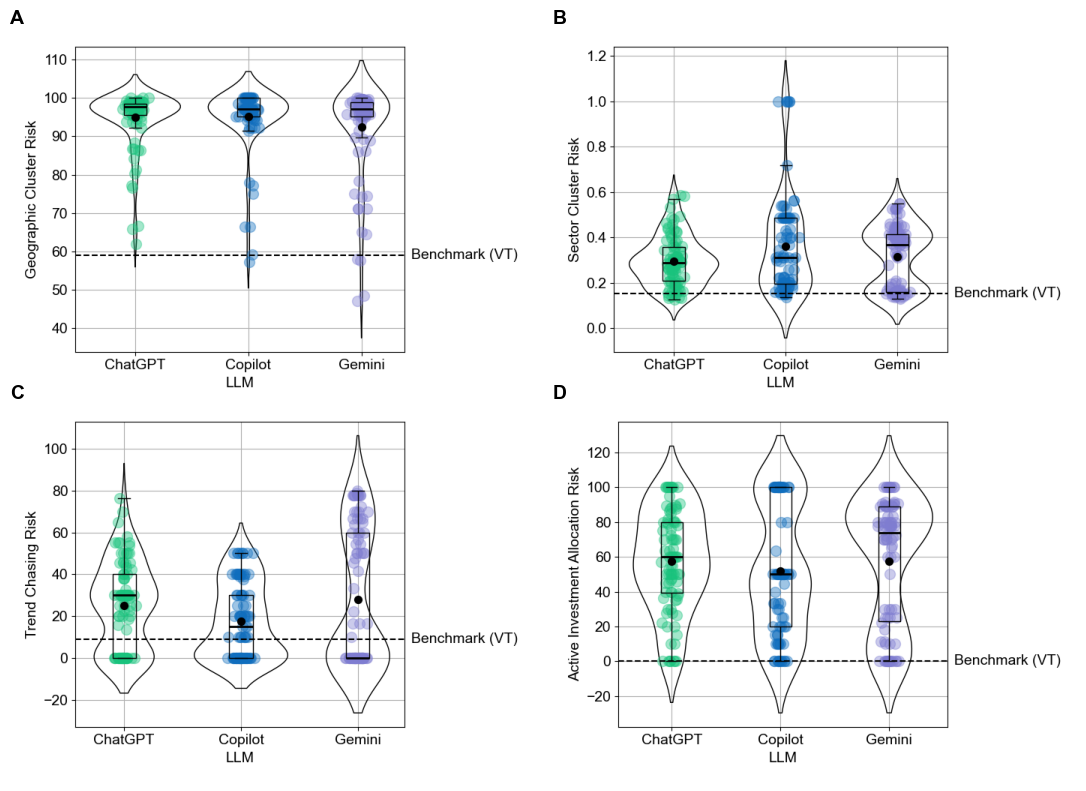

In [3]:
from matplotlib.gridspec import GridSpec
from PIL import Image

img1 = Image.open('./figures/study1_geoRisk.png')
img2 = Image.open('./figures/study1_sectorRisk.png')
img3 = Image.open('./figures/study1_trendRisk.png')
img4 = Image.open('./figures/study1_activeRisk.png')

fig = plt.figure(figsize=(11, 8))

gs = GridSpec(2, 2, height_ratios=[1, 1])

def add_fig(fig, gs, position, img, lab):
    ax = fig.add_subplot(gs[position])
    ax.set_title(lab, fontweight='bold', loc='left', fontsize=14, fontfamily='Arial')
    ax.imshow(img)
    ax.axis('off')

# Add images to the grid
add_fig(fig, gs, (0, 0), img1, 'A') 
add_fig(fig, gs, (0, 1), img2, 'B')
add_fig(fig, gs, (1, 0), img3, 'C')
add_fig(fig, gs, (1, 1), img4, 'D')

plt.tight_layout()
plt.subplots_adjust(hspace= 0)

plt.savefig('./figures/study1_panels.png')

plt.show()